In [258]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score)

In [230]:
df = pd.read_csv("retail_customer_churn_100k (1).csv")

In [231]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   customer_id            100000 non-null  object 
 1   age_group              100000 non-null  object 
 2   gender                 100000 non-null  object 
 3   region                 100000 non-null  object 
 4   customer_segment       100000 non-null  object 
 5   preferred_channel      100000 non-null  object 
 6   purchase_frequency     100000 non-null  int64  
 7   avg_order_value        100000 non-null  float64
 8   total_spent            100000 non-null  float64
 9   recency_days           100000 non-null  int64  
 10  website_visits         100000 non-null  int64  
 11  discount_usage_rate    100000 non-null  float64
 12  email_open_rate        100000 non-null  float64
 13  cart_abandonment_rate  100000 non-null  float64
 14  loyalty_score          100000 non-nul

In [232]:
df.head(20)

,customer_id,age_group,gender,region,customer_segment,preferred_channel,purchase_frequency,avg_order_value,total_spent,recency_days,website_visits,discount_usage_rate,email_open_rate,cart_abandonment_rate,loyalty_score,engagement_score,churn_risk,churn_flag
0,C000001,18-24,Other,North,Loyal,Online,5,381.27,2108.80,189,27,0.38,0.13,0.42,33,35.5,Medium,1
1,C000002,25-34,Other,South,New,Mobile App,12,376.65,3843.06,277,68,0.51,0.06,0.07,68,49.5,Medium,1
2,C000003,55+,Other,North,VIP,Online,5,37.73,224.65,271,23,0.64,0.22,0.46,73,38.0,High,1
3,C000004,18-24,Male,North,Returning,Mobile App,12,191.19,1960.79,89,93,0.66,0.31,0.13,93,59.0,Low,0
4,C000005,55+,Other,North,Returning,Mobile App,2,279.64,594.79,264,4,0.73,0.27,0.58,11,34.5,High,1
5,C000006,55+,Male,West,VIP,Mobile App,8,31.90,292.15,44,61,0.72,0.56,0.79,81,38.5,Low,0
6,C000007,35-44,Male,North,VIP,In-Store,8,217.92,2068.34,213,34,0.25,0.75,0.34,69,70.5,Medium,0
7,C000008,35-44,Male,South,Loyal,Online,20,48.33,1155.48,344,87,0.27,0.06,0.21,17,42.5,High,1
8,C000009,18-24,Male,West,Loyal,In-Store,12,313.08,3290.78,231,70,0.74,0.77,0.41,42,68.0,Medium,1
9,C000010,55+,Male,East,VIP,Mobile App,3,297.25,956.98,35,14,0.14,0.66,0.66,99,50.0,Low,0


In [233]:
df.describe()

,purchase_frequency,avg_order_value,total_spent,recency_days,website_visits,discount_usage_rate,email_open_rate,cart_abandonment_rate,loyalty_score,engagement_score,churn_flag
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000
mean,11.802220,209.704723,2543.890827,182.740540,58.524370,0.426245,0.474519,0.450982,54.61683,51.176860,0.462240
std,14.368458,109.710192,3790.838484,105.123047,78.797453,0.217042,0.245401,0.230493,25.96110,16.829141,0.498575
min,1.000000,20.030000,17.870000,1.000000,2.000000,0.050000,0.050000,0.050000,10.00000,10.000000,0.000000
25%,2.000000,114.610000,381.317500,92.000000,10.000000,0.240000,0.260000,0.250000,32.00000,39.000000,0.000000
50%,8.000000,209.485000,1089.180000,182.000000,29.000000,0.430000,0.470000,0.450000,55.00000,51.000000,0.000000
75%,12.000000,304.750000,2952.172500,274.000000,71.000000,0.610000,0.690000,0.650000,77.00000,63.000000,1.000000
max,60.000000,400.000000,28444.240000,364.000000,479.000000,0.800000,0.900000,0.850000,99.00000,92.000000,1.000000


In [234]:
df.duplicated().sum()

np.int64(0)

In [235]:
df.drop(columns=["customer_id", "churn_risk"], inplace=True)

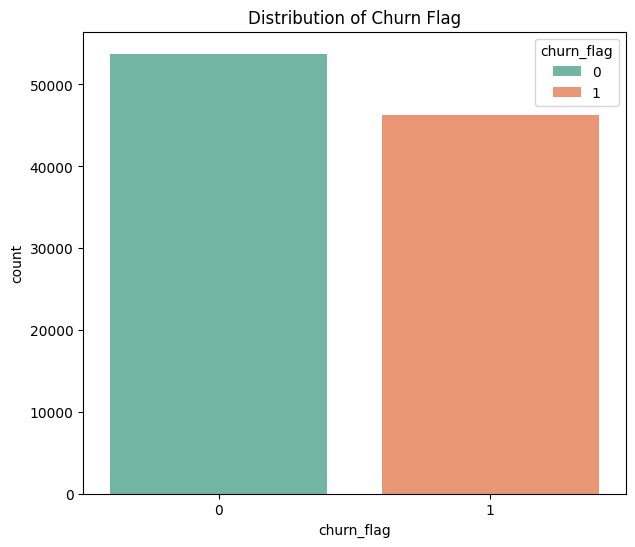

In [236]:
plt.figure(figsize=(7, 6))
sns.countplot(x='churn_flag',hue='churn_flag', data=df, palette='Set2')
plt.title('Distribution of Churn Flag')
plt.show()

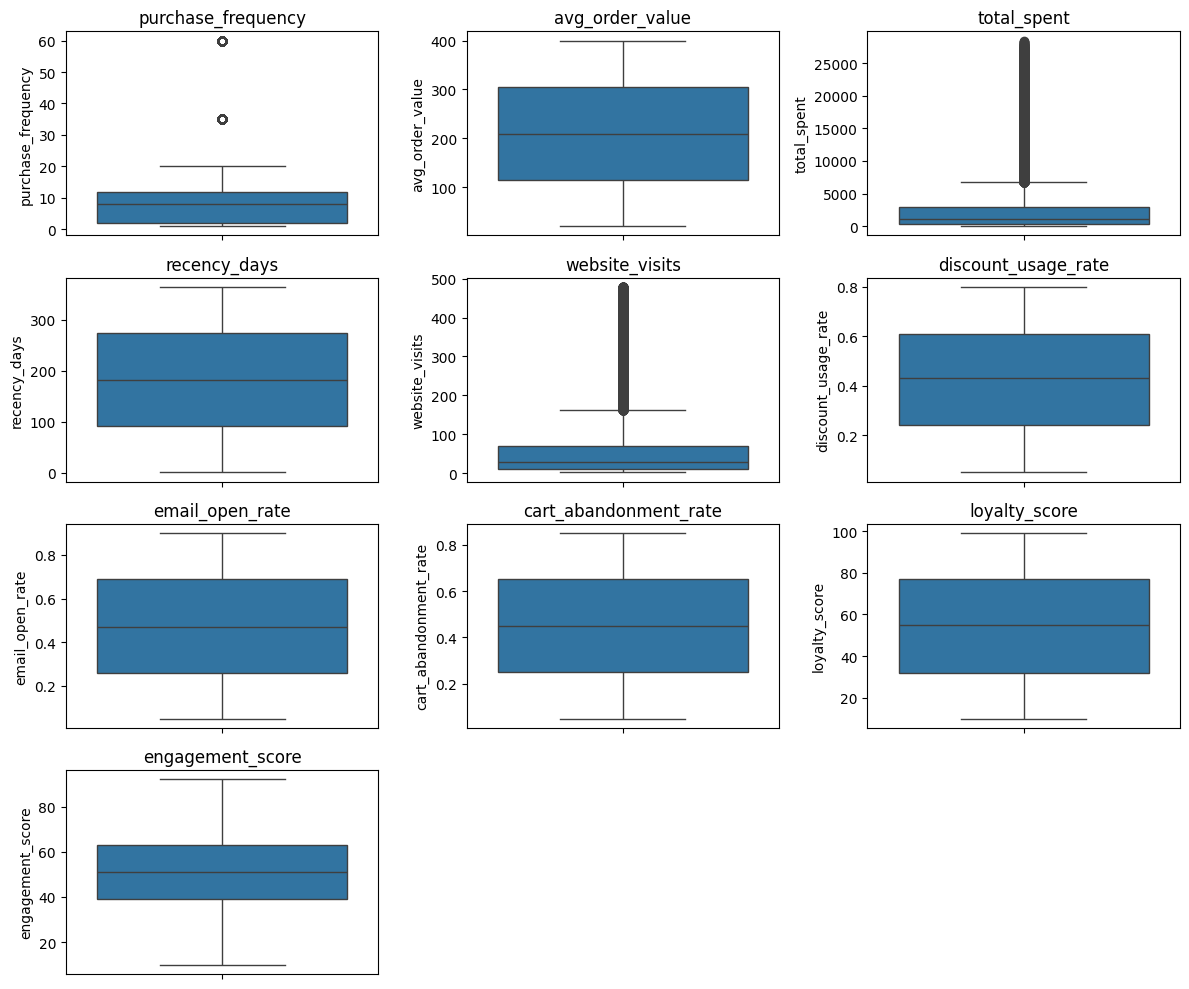

In [237]:
num_cols = ['purchase_frequency','avg_order_value','total_spent','recency_days','website_visits',
            'discount_usage_rate','email_open_rate','cart_abandonment_rate','loyalty_score','engagement_score']

plt.figure(figsize=(12, 10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

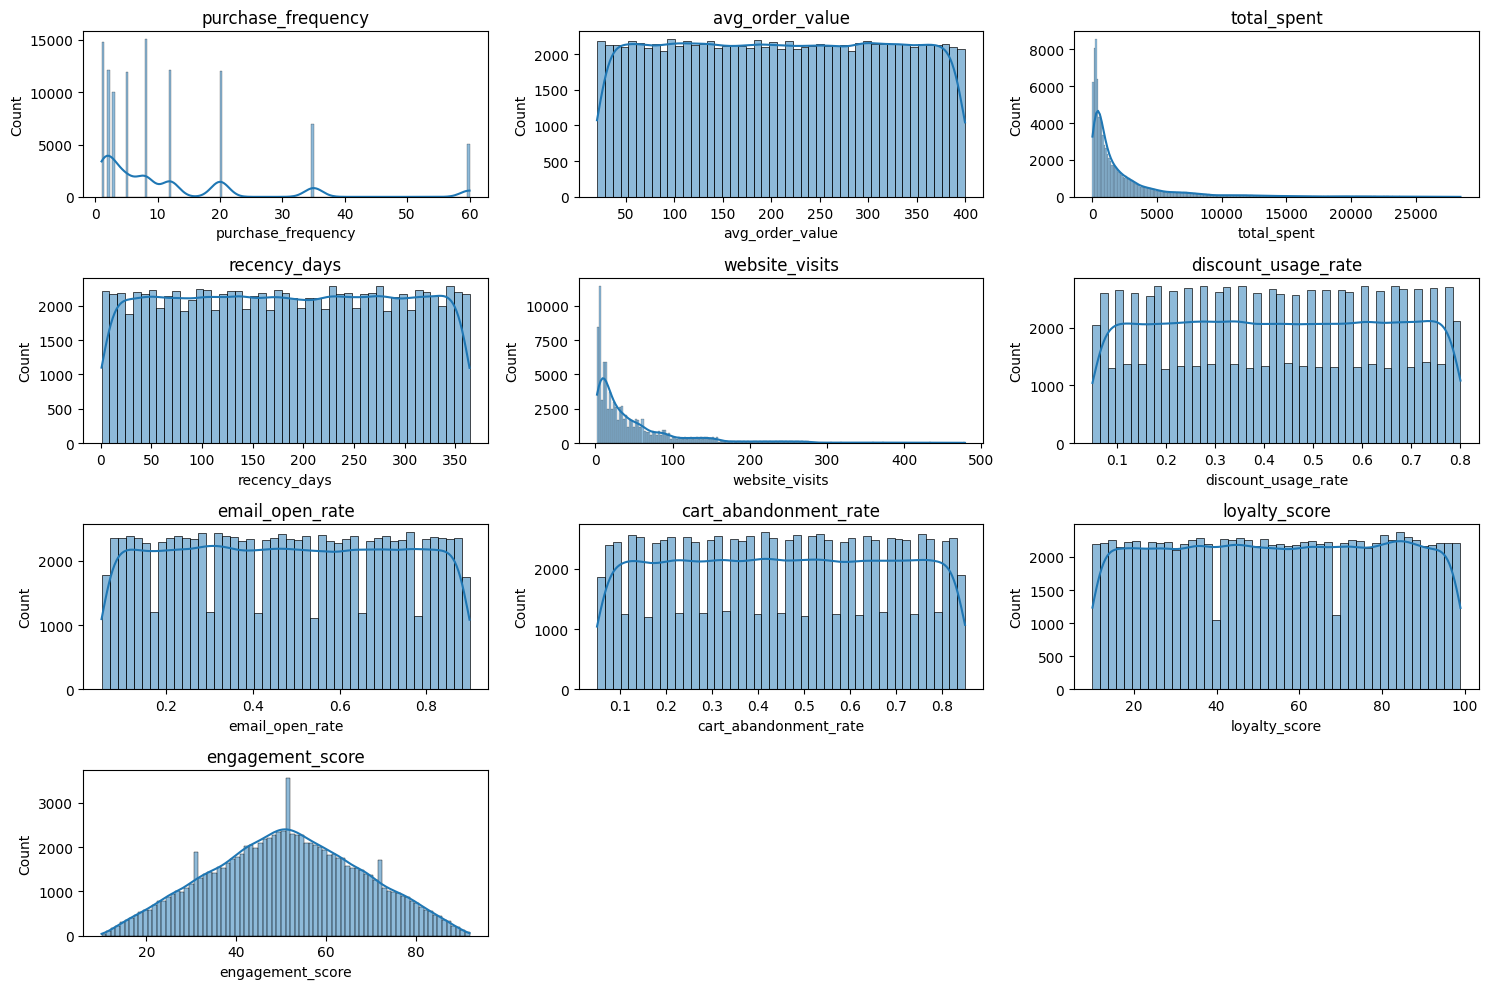

In [238]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(4, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

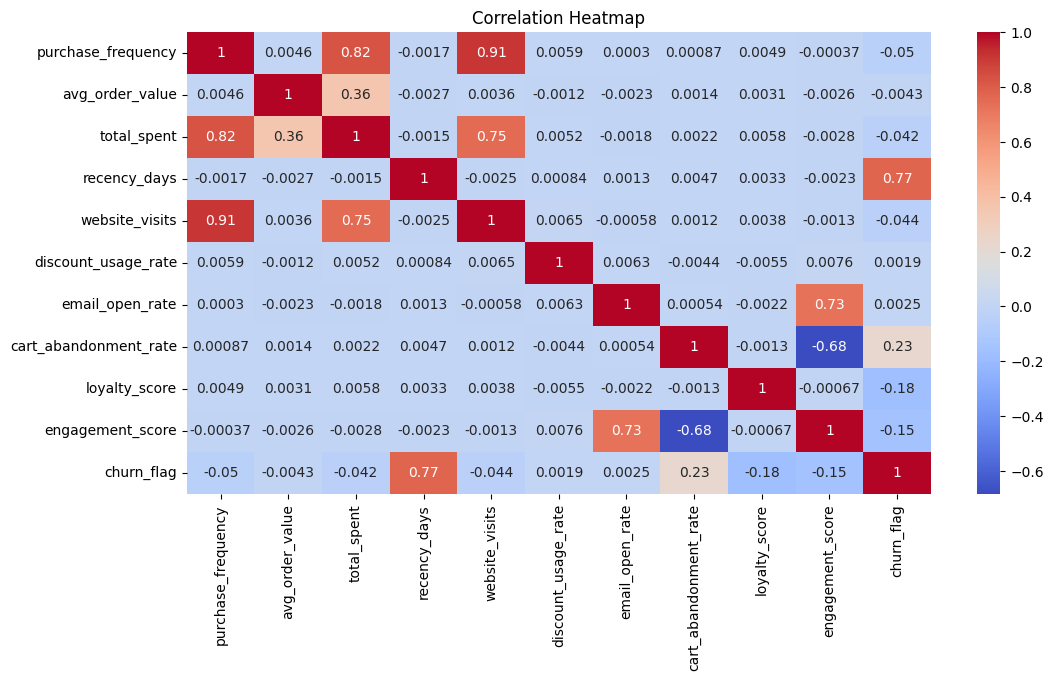

In [239]:
plt.figure(figsize=(12, 6))
heatmap = sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


In [240]:
# train test split
X = df.drop(columns=['churn_flag'])
y = df['churn_flag']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [257]:
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X_train.select_dtypes(include=['object']).columns

In [242]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ]
)

preprocessor_tree = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

In [243]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('classifier', RandomForestClassifier(random_state=42))
])

gb_pipeline = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('classifier', GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    ))
])

et_pipeline = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('classifier', ExtraTreesClassifier(random_state=42))
])

In [244]:
models = {
    'Logistic Regression': lr_pipeline,
    'Random Forest': rf_pipeline,
    'Gradient Boosting': gb_pipeline,
    'Extra Trees': et_pipeline    
}

In [245]:
# Cross Validation
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=skf,
        scoring='roc_auc'
    )

    print(f"{name}:")
    print("Mean ROC-AUC:", scores.mean())
    print("Std:", scores.std())
    print("-" * 40)

Logistic Regression:
Mean ROC-AUC: 0.9902141450787351
Std: 0.0007468603384807543
----------------------------------------
Random Forest:
Mean ROC-AUC: 0.9878144455059676
Std: 0.000880306542980745
----------------------------------------
Gradient Boosting:
Mean ROC-AUC: 0.9893812866246066
Std: 0.0008088516692200511
----------------------------------------
Extra Trees:
Mean ROC-AUC: 0.9877353843685682
Std: 0.0008475783479184392
----------------------------------------


In [246]:
# Train Models
for name, model in models.items():
    model.fit(X_train, y_train)

def evaluate_model(model, X_test, y_test):

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    return {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }

In [247]:
# Evaluate on Test Set

results = {}

for name, model in models.items():
    results[name] = evaluate_model(
        model,
        X_test,
        y_test
    )

results_df = pd.DataFrame(results).T
results_df.sort_values(
    'ROC-AUC',
    ascending=False
)

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.94535,0.941221,0.940508,0.940865,0.990375
Gradient Boosting,0.94445,0.940628,0.939102,0.939865,0.989707
Random Forest,0.94070,0.935763,0.935965,0.935864,0.988405
Extra Trees,0.94000,0.939281,0.930341,0.934790,0.988372


In [ ]:
best_model = models['Logistic Regression']

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

In [ ]:
joblib.dump(best_model,
            r"C:\Users\VIMAL\AppData\Local\Temp\churn_model.pkl")

model = joblib.load("churn_model.pkl")
print(type(model))

<class 'sklearn.pipeline.Pipeline'>


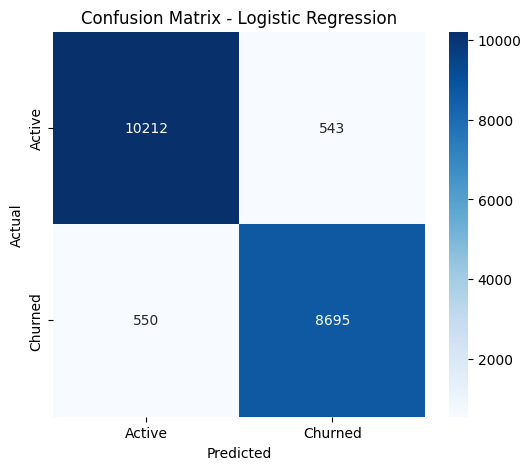

In [249]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Active', 'Churned'],
    yticklabels=['Active', 'Churned']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

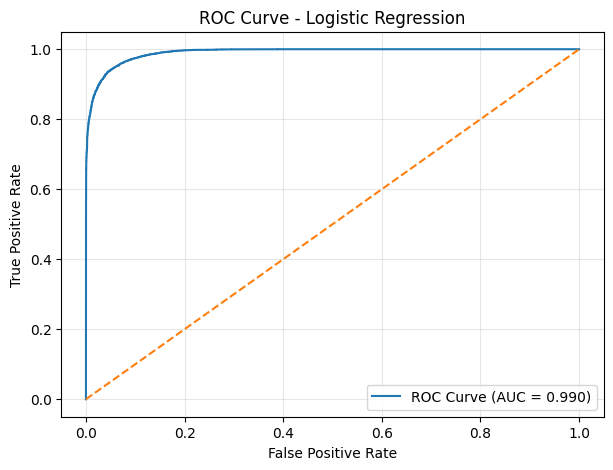

In [250]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

In [251]:
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': best_model.named_steps['classifier'].coef_[0]
})

coef_df = coef_df.reindex(
    coef_df['Coefficient'].abs().sort_values(ascending=False).index
)

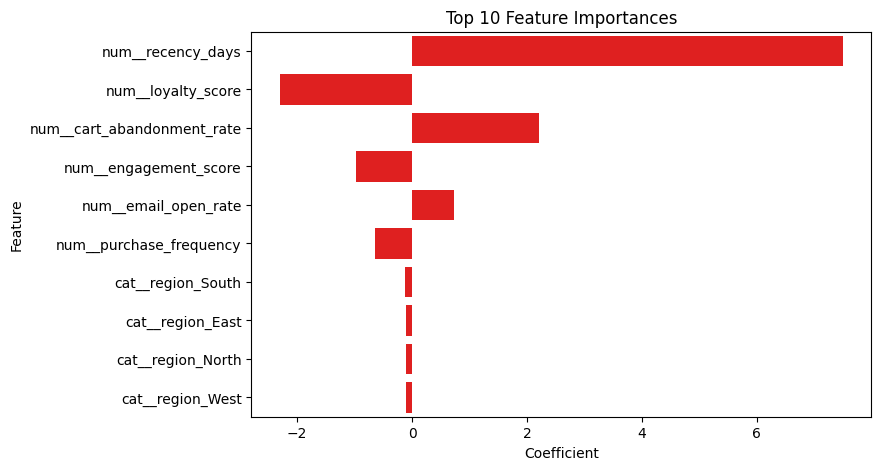

In [252]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=coef_df.head(10),
    x='Coefficient',
    y='Feature',
    color='red'
)

plt.title('Top 10 Feature Importances')
plt.show()

In [253]:
X_test_transformed = best_model.named_steps['preprocessor'].transform(X_test)

explainer = shap.LinearExplainer(
    best_model.named_steps['classifier'],
    X_test_transformed
)

shap_values = explainer.shap_values(X_test_transformed)

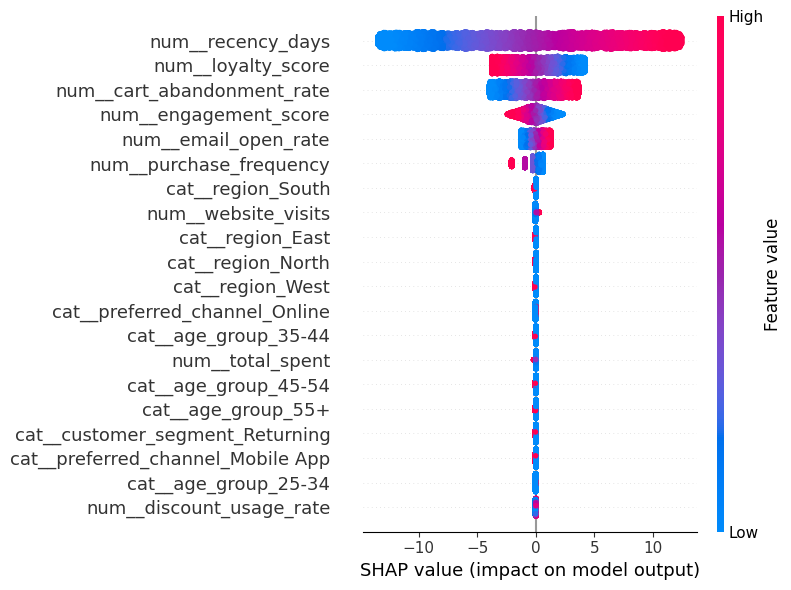

In [254]:
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

plt.figure(figsize=(7, 5))
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    plot_size=(8,6)
)

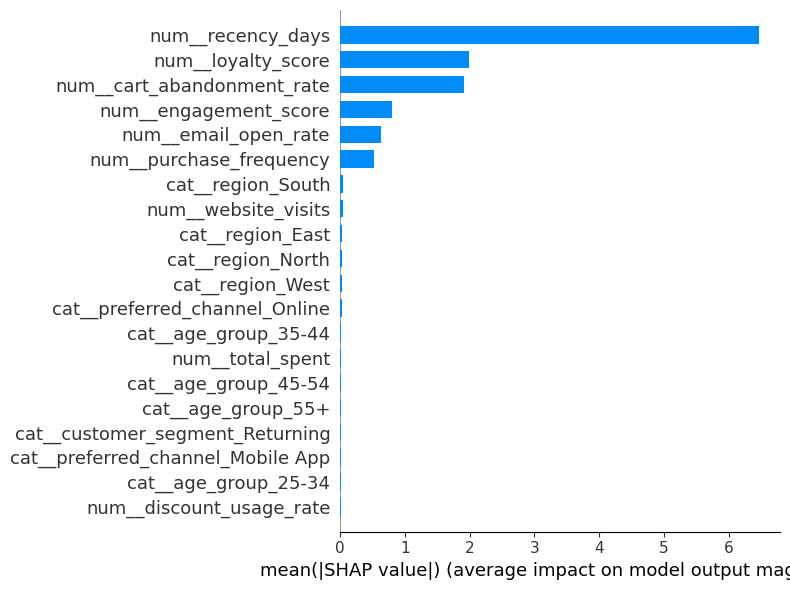

In [255]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    plot_type='bar',
    plot_size=(8,6)
)